In [63]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split # 데이터셋 분리 함수
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential, save_model, load_model
# 과적합을 줄이기위한 방법 : dropout, 배치 정규화, L2 정규화
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
# 데이터 불균형 극복
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

<font size="5" color="black">ch06. 로지스틱 회귀, 분류 - 과적합 방지 (심장병 발병 예측)</font>

```
age: 환자의 나이 (년 단위)
sex: 환자의 성별 (1 = 남성, 0 = 여성)
cp (Chest Pain Type): 흉통의 종류 (0~3 또는 1~4) - 전형적 협심증(Typical angina), 비전형적 협심증(Atypical angina), 비협심증성 통증(Non-anginal pain), 무증상(Asymptomatic)
trestbps: 안정 시 혈압 (입원 시 mm Hg 기준)
chol: 혈청 콜레스테롤 수치 (mg/dl)
fbs: 공복 혈당이 120 mg/dl 초과하는지 여부 (1 = 참, 0 = 거짓)
restecg: 안정 시 심전도 결과 (0 = 정상, 1 = ST-T 파동 이상, 2 = 좌심실 비대 소견)
thalach: 최대 심박수exang: 운동 유발 협심증 여부 (1 = 있음, 0 = 없음)
oldpeak: 안정 시와 비교한 운동으로 인한 ST 분절 하강 수치
slope: 최고 운동 시 ST 분절의 기울기 (상향/평탄/하향)
ca: 형광 투시법으로 확인된 주요 혈관 수 (0~3개)
thal: 지중해빈혈 등 혈액 관련 결함 유형 (정상, 고정 결함, 가역적 결함)
target (class): 심장 질환 진단 결과 (0 = 정상/건강, 1 = 심장병 발병/혈관 협착 50% 초과)
```

# 1. 로지스틱 회귀 분석 (이진분류)
- 데이터 생성 및 전처리
    * 엑셀 - 데이터프레임 - 결측치 처리 - X, y 분리, scale 조정, 데이터셋 분리
- 모델 생성, 학습과정설정, 학습
- 모델 평가 (시각화, 평가, 교차표)
- 모델 사용 (저장, 예측)

## 1.1 데이터 생성 및 전처리

In [3]:
# openpyxl : xlsx 파일을 읽고 쓰는 라이브러리 
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
df = pd.read_excel('data/heart-disease.xlsx')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [6]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [7]:
df.isin(['?']).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [10]:
df[(df['chol']=='?')|(df['ca']=='?')|(df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [11]:
# 방법 1 : ?가 있는 행 삭제
drop_idx = df[(df['chol']=='?')|(df['ca']=='?')|(df['hsl']=='?')].index
df.drop(drop_idx)

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0,7,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,1


In [12]:
# 방법 2 : ?를 결측치로 대체 후 결측치 삭제
df = df.replace('?', np.nan)

In [13]:
# 결측치가 포함된 데이터 추출
df[(df['chol'].isna()|df['ca'].isna()|df['hsl'].isna())]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
87,53,0,3,128,216.0,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223.0,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247.0,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204.0,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220.0,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175.0,0,0,173,0,0.0,1,NaN,3.0,0


In [14]:
# 결측치 처리 : dropna(), fillna(), apply()
df = df.dropna(how='any').reset_index(drop=True) # 결측치가 하나의 요소라도 있을 경우, 해당 행 삭제

In [15]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [16]:
df.shape

(296, 14)

In [17]:
# 타겟변수 균형 확인
df['heartDisease'].value_counts()/df.shape[0]
df['heartDisease'].value_counts(normalize=True)

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [18]:
# X, y 분리
X = df.iloc[:,:-1].values
y = df.iloc[:,-1:].values
X.shape, y.shape

((296, 13), (296, 1))

In [19]:
# X 변수의 scale 조정

scaler = StandardScaler()

scaled_X = scaler.fit_transform(X)

In [20]:
# 데이터셋 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y,
                                                    #train_size=0.8 - test_size 지정 시 자동 처리
                                                    test_size=0.2,
                                                    random_state=7, # 난수 시드(Seed)값
                                                    stratify=y # 층화 추출 : 비율을 그대로 유지하면서 데이터를 쪼개는 방식
                                                   )

In [21]:
# 종속 변수 균형 확인
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.542373
1    0.457627
dtype: float64
0    0.533333
1    0.466667
dtype: float64


## 1.2 모델 생성 & 학습과정 설정 & 학습

### 과적합을 줄이기 위한 방법
- Dropout : 훈련 시 설정한 비율(예: 0.2)만큼 뉴런을 임의로 꺼버려, 특정 뉴런에만 의존하는 '암기식 학습'을 방지
- BatchNormalization : 미니배치 단위로 평균 0, 표준편차 1로 정규화하여 학습 품질과 속도 향상
- L2 Regularization : 손실 함수에 가중치 제곱합을 추가하여 가중치($w$)가 너무 커지지 않게 제약을 걸어 과적합 방지

**BatchNormalization 파라미터 구조 (출력 노드가 32개일 때)**
    - 노드 수($N$)의 **4배**(총 128개) 파라미터가 생성

1. 학습되는 파라미터 (64개): 직접 가중치를 조정하며 최적화하는 변수
* `gamma` (32개): 데이터 폭(스케일) 조절
* `beta` (32개): 데이터 위치(이동) 조절


2. 학습되지 않는 파라미터 (64개): 학습 중 평균/분산 기록용 (실제 테스트 시 사용)
* `moving_mean` (32개): 평균의 이동 기록
* `moving_variance` (32개): 분산의 이동 기록

In [22]:
model = Sequential()

model.add(Input(shape=(13,)))

model.add(Dense(units=52, activation='elu', 
                kernel_regularizer=l2(0.001) # l2 정규화
               ))
model.add(BatchNormalization()) # 배치 정규화
model.add(Dropout(0.4)) # 드롭아웃

# Dense >> BatchNormalization >> Dropout 순서가 가장 안정적
model.add(Dense(units=26, activation='relu', 
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(units=13, activation='elu', 
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 52)                728       
                                                                 
 batch_normalization (BatchN  (None, 52)               208       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 52)                0         
                                                                 
 dense_1 (Dense)             (None, 26)                1378      
                                                                 
 batch_normalization_1 (Batc  (None, 26)               104       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 26)                0

In [23]:
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.optimizers import Adam

model.compile(loss='binary_crossentropy', optimizer='adam', 
                                    metrics=['accuracy', 
                                             Recall(name='recall'), # 재현율
                                             Precision(name='precision')]) # 정밀도

In [24]:
# 클래스(0/1) 손실 가중치 계산 (학습 데이터가 불균형할 때 학습 시 50:50의 중요도로 체감하도록 손실에 가중치 부여)
from sklearn.utils.class_weight import compute_class_weight

y_train_flat = y_train.flatten() #y_train.reshape(-1)

class_weight = compute_class_weight(
                            class_weight='balanced', # 'balanced' 옵션: 전체 샘플 수 / (클래스 수 * 클래스별 샘플 수) 공식으로 가중치 자동 산출
                            classes=np.unique(y_train_flat),
                            y = y_train_flat) # 반드시 1차원
print('class_weight :', class_weight)

class_weight_dict = dict(enumerate(class_weight))
print('class_weight_dict :', class_weight_dict)

# y_train의 빈도수
values, counts = np.unique(y_train_flat, return_counts=True)
print('빈도수 : ', dict(zip(values, counts)))
print(counts[0]*class_weight_dict[0], counts[1]*class_weight_dict[1]) # 빈도가 같아짐

ratios = counts/counts.sum()
print(ratios[0]*class_weight_dict[0], ratios[1]*class_weight_dict[1])

class_weight : [0.921875   1.09259259]
class_weight_dict : {0: 0.921875, 1: 1.0925925925925926}
빈도수 :  {0: 128, 1: 108}
118.0 118.0
0.5 0.5


In [25]:
# callback : 모델이 학습하는 동안 특정 시점마다 자동으로 실행되도록 등록해두는 보조 함수
# ReduceLROnPlateau : loss이 정체될 때 학습률을 소폭 감소시켜 최적화 수렴을 돕는 콜백
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # 검증 손실 관찰
    factor=0.5,          # 손실 정체 시 학습률을 0.5배로 감소
    patience=5,          # 5 에포크 동안 개선이 없으면 발동
    min_lr=0.000001       # 최소 학습률 제한
)

In [26]:
hist = model.fit(X_train, y_train,
                epochs=200,
                batch_size=100,
                validation_split=0.2,
                class_weight=class_weight_dict,
                callbacks=[reduce_lr],
                verbose=1)

Epoch 1/200
2/2 [==============================] - 2s 535ms/step - loss: 0.8087 - accuracy: 0.6543 - recall: 0.5977 - precision: 0.6341 - val_loss: 0.7571 - val_accuracy: 0.5625 - val_recall: 1.0000 - val_precision: 0.5000 - lr: 0.0010
Epoch 2/200
2/2 [==============================] - 0s 57ms/step - loss: 0.8584 - accuracy: 0.6170 - recall: 0.5632 - precision: 0.5904 - val_loss: 0.7410 - val_accuracy: 0.5833 - val_recall: 1.0000 - val_precision: 0.5122 - lr: 0.0010
Epoch 3/200
2/2 [==============================] - 0s 63ms/step - loss: 0.8687 - accuracy: 0.5798 - recall: 0.5287 - precision: 0.5476 - val_loss: 0.7249 - val_accuracy: 0.6042 - val_recall: 1.0000 - val_precision: 0.5250 - lr: 0.0010
Epoch 4/200
2/2 [==============================] - 0s 50ms/step - loss: 0.7768 - accuracy: 0.6383 - recall: 0.6207 - precision: 0.6067 - val_loss: 0.7096 - val_accuracy: 0.6250 - val_recall: 1.0000 - val_precision: 0.5385 - lr: 0.0010
Epoch 5/200
2/2 [==============================] - 0s 45ms/

Epoch 36/200
2/2 [==============================] - 0s 41ms/step - loss: 0.5315 - accuracy: 0.7926 - recall: 0.8046 - precision: 0.7609 - val_loss: 0.4947 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - lr: 0.0010
Epoch 37/200
2/2 [==============================] - 0s 47ms/step - loss: 0.5234 - accuracy: 0.8085 - recall: 0.7701 - precision: 0.8072 - val_loss: 0.4928 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - lr: 0.0010
Epoch 38/200
2/2 [==============================] - 0s 39ms/step - loss: 0.5544 - accuracy: 0.7819 - recall: 0.7241 - precision: 0.7875 - val_loss: 0.4915 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - lr: 0.0010
Epoch 39/200
2/2 [==============================] - 0s 61ms/step - loss: 0.5155 - accuracy: 0.7819 - recall: 0.7816 - precision: 0.7556 - val_loss: 0.4898 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - lr: 0.0010
Epoch 40/200
2/2 [==============================] - 0s 4

Epoch 71/200
2/2 [==============================] - 0s 45ms/step - loss: 0.4559 - accuracy: 0.8351 - recall: 0.8391 - precision: 0.8111 - val_loss: 0.4739 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 0.0010
Epoch 72/200
2/2 [==============================] - 0s 47ms/step - loss: 0.5024 - accuracy: 0.8085 - recall: 0.7931 - precision: 0.7931 - val_loss: 0.4737 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 0.0010
Epoch 73/200
2/2 [==============================] - 0s 43ms/step - loss: 0.4596 - accuracy: 0.8404 - recall: 0.8276 - precision: 0.8276 - val_loss: 0.4740 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 0.0010
Epoch 74/200
2/2 [==============================] - 0s 42ms/step - loss: 0.4467 - accuracy: 0.8245 - recall: 0.8391 - precision: 0.7935 - val_loss: 0.4738 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 0.0010
Epoch 75/200
2/2 [==============================] - 0s 4

2/2 [==============================] - 0s 54ms/step - loss: 0.5061 - accuracy: 0.8138 - recall: 0.8046 - precision: 0.7955 - val_loss: 0.4811 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 140/200
2/2 [==============================] - 0s 48ms/step - loss: 0.4514 - accuracy: 0.8457 - recall: 0.8506 - precision: 0.8222 - val_loss: 0.4812 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 141/200
2/2 [==============================] - 0s 43ms/step - loss: 0.4703 - accuracy: 0.8351 - recall: 0.8276 - precision: 0.8182 - val_loss: 0.4812 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 142/200
2/2 [==============================] - 0s 50ms/step - loss: 0.4612 - accuracy: 0.8351 - recall: 0.8276 - precision: 0.8182 - val_loss: 0.4811 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 143/200
2/2 [==============================]

2/2 [==============================] - 0s 50ms/step - loss: 0.5051 - accuracy: 0.8032 - recall: 0.7931 - precision: 0.7841 - val_loss: 0.4810 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 174/200
2/2 [==============================] - 0s 54ms/step - loss: 0.4830 - accuracy: 0.8191 - recall: 0.7816 - precision: 0.8193 - val_loss: 0.4811 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 175/200
2/2 [==============================] - 0s 40ms/step - loss: 0.4377 - accuracy: 0.8298 - recall: 0.8161 - precision: 0.8161 - val_loss: 0.4811 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 176/200
2/2 [==============================] - 0s 47ms/step - loss: 0.4098 - accuracy: 0.8564 - recall: 0.8161 - precision: 0.8659 - val_loss: 0.4811 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.0000e-06
Epoch 177/200
2/2 [==============================]

## 1.3 모델 평가 (시각화, 평가, 교차표)

In [27]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision', 'lr'])

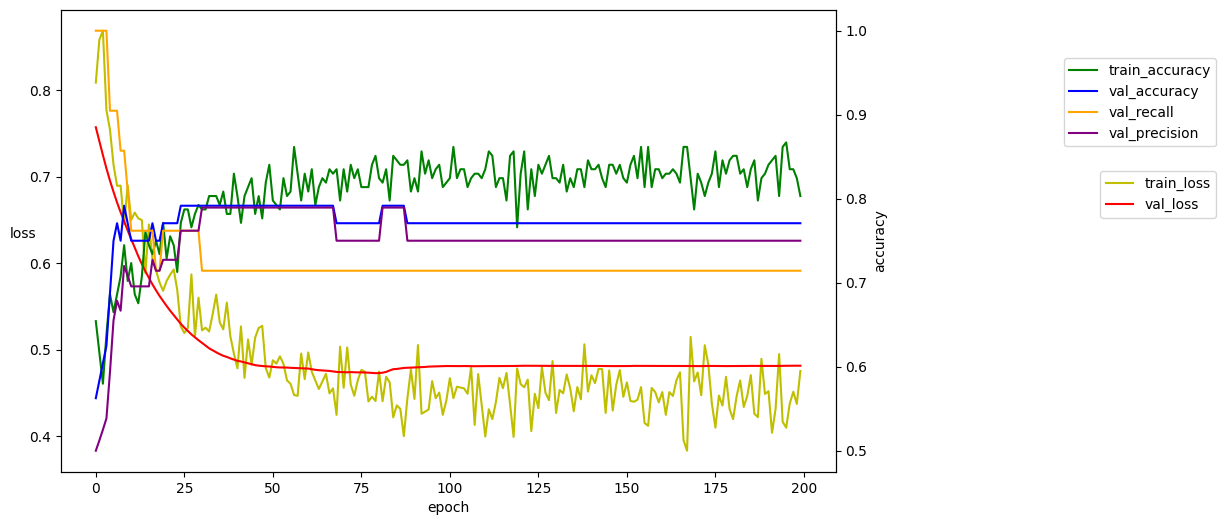

In [28]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'orange', label='val_recall')
acc_ax.plot(hist.history['val_precision'], 'purple', label='val_precision')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

In [29]:
loss, accuracy, recall, precision = model.evaluate(X_test, y_test)
print(f'정확도 : {accuracy*100:.2f}%')

2/2 [==============================] - 0s 2ms/step - loss: 0.4940 - accuracy: 0.8000 - recall: 0.8571 - precision: 0.7500
정확도 : 80.00%


In [30]:
y_hat = (model.predict(X_test)>0.5).astype(int)

2/2 [==============================] - 0s 0s/step


In [31]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[24,  8],
       [ 4, 24]], dtype=int64)

In [32]:
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1_score:.4f} ({f1_score*100:.2f}%)")

Accuracy : 0.8000 (80.00%)
Precision: 0.7500 (75.00%)
Recall   : 0.8571 (85.71%)
F1-Score : 0.8000 (80.00%)


## 1.4 모델 사용

In [33]:
save_model(model, 'model/05_heart.h5')

In [34]:
model2 = load_model('model/05_heart.h5')

In [35]:
X[0]

array([ 63. ,   1. ,   1. , 145. , 233. ,   1. ,   2. , 150. ,   0. ,
         2.3,   3. ,   0. ,   6. ])

In [36]:
data = [[ 63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6]]
input_data = scaler.transform(data)
(model.predict(input_data)>= 0.5).astype(int)[0][0]

1/1 [==============================] - 0s 18ms/step


0

# 2. 분류 분석
- 데이터 생성 및 전처리 : 타겟변수 원-핫 인코딩
    * X_train, y_train, X_test, y_test -> y_train & y_test : 원-핫 인코딩
- 모델 생성, 학습과정설정, 학습
- 모델 평가 (시각화, 평가, 교차표)
- 모델 사용 (저장, 예측)

## 2.1 데이터 생성 및 전처리

In [37]:
Y_train = to_categorical(y_train, 2)
Y_test = to_categorical(y_test, 2)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((236, 13), (236, 2), (60, 13), (60, 2))

## 2.2 모델 생성 & 학습과정 설정 & 학습

In [38]:
model = Sequential()

model.add(Input(shape=(13,)))

model.add(Dense(units=52, activation='elu', 
                kernel_regularizer=l2(0.001) # l2 정규화
               ))
model.add(BatchNormalization()) # 배치 정규화
model.add(Dropout(0.4)) # 드롭아웃

# Dense >> BatchNormalization >> Dropout 순서가 가장 안정적
model.add(Dense(units=26, activation='relu', 
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(units=13, activation='elu', 
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 52)                728       
                                                                 
 batch_normalization_3 (Batc  (None, 52)               208       
 hNormalization)                                                 
                                                                 
 dropout_3 (Dropout)         (None, 52)                0         
                                                                 
 dense_5 (Dense)             (None, 26)                1378      
                                                                 
 batch_normalization_4 (Batc  (None, 26)               104       
 hNormalization)                                                 
                                                                 
 dropout_4 (Dropout)         (None, 26)               

In [39]:
model.compile(loss='categorical_crossentropy', optimizer='adam', 
                                    metrics=['accuracy', 
                                             Recall(name='recall'), # 재현율
                                             Precision(name='precision')]) # 정밀도

In [40]:
y_train_flat = y_train.flatten() #y_train.reshape(-1)

class_weight = compute_class_weight(
                            class_weight='balanced', # 'balanced' 옵션: 전체 샘플 수 / (클래스 수 * 클래스별 샘플 수) 공식으로 가중치 자동 산출
                            classes=np.unique(y_train_flat),
                            y = y_train_flat) # 반드시 1차원

class_weight_dict = dict(enumerate(class_weight))

In [41]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.000001
)

In [42]:
hist = model.fit(X_train, Y_train,
                epochs=200,
                validation_split=0.2,
                class_weight=class_weight_dict,
                callbacks=[reduce_lr],
                verbose=1)

Epoch 1/200
6/6 [==============================] - 2s 97ms/step - loss: 1.0121 - accuracy: 0.4468 - recall: 0.4468 - precision: 0.4468 - val_loss: 0.7888 - val_accuracy: 0.4792 - val_recall: 0.4792 - val_precision: 0.4792 - lr: 0.0010
Epoch 2/200
6/6 [==============================] - 0s 14ms/step - loss: 1.0100 - accuracy: 0.4681 - recall: 0.4681 - precision: 0.4681 - val_loss: 0.7258 - val_accuracy: 0.6667 - val_recall: 0.6667 - val_precision: 0.6667 - lr: 0.0010
Epoch 3/200
6/6 [==============================] - 0s 13ms/step - loss: 0.9020 - accuracy: 0.5638 - recall: 0.5638 - precision: 0.5638 - val_loss: 0.6787 - val_accuracy: 0.7292 - val_recall: 0.7292 - val_precision: 0.7292 - lr: 0.0010
Epoch 4/200
6/6 [==============================] - 0s 12ms/step - loss: 0.8261 - accuracy: 0.5957 - recall: 0.5957 - precision: 0.5957 - val_loss: 0.6453 - val_accuracy: 0.7500 - val_recall: 0.7500 - val_precision: 0.7500 - lr: 0.0010
Epoch 5/200
6/6 [==============================] - 0s 14ms/s

Epoch 36/200
6/6 [==============================] - 0s 15ms/step - loss: 0.4933 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4329 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 0.0010
Epoch 37/200
6/6 [==============================] - 0s 12ms/step - loss: 0.5217 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4349 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 5.0000e-04
Epoch 38/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4592 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4358 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 5.0000e-04
Epoch 39/200
6/6 [==============================] - 0s 12ms/step - loss: 0.5043 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4353 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 5.0000e-04
Epoch 40/200
6/6 [==========================

6/6 [==============================] - 0s 15ms/step - loss: 0.5037 - accuracy: 0.7819 - recall: 0.7819 - precision: 0.7819 - val_loss: 0.4387 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 105/200
6/6 [==============================] - 0s 14ms/step - loss: 0.4990 - accuracy: 0.8085 - recall: 0.8085 - precision: 0.8085 - val_loss: 0.4387 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 106/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4428 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4387 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 107/200
6/6 [==============================] - 0s 12ms/step - loss: 0.5135 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.4388 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 108/200
6/6 [==============================]

6/6 [==============================] - 0s 12ms/step - loss: 0.5473 - accuracy: 0.7660 - recall: 0.7660 - precision: 0.7660 - val_loss: 0.4392 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 139/200
6/6 [==============================] - 0s 10ms/step - loss: 0.4543 - accuracy: 0.8457 - recall: 0.8457 - precision: 0.8457 - val_loss: 0.4390 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 140/200
6/6 [==============================] - 0s 11ms/step - loss: 0.4728 - accuracy: 0.7819 - recall: 0.7819 - precision: 0.7819 - val_loss: 0.4387 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 141/200
6/6 [==============================] - 0s 17ms/step - loss: 0.4685 - accuracy: 0.8032 - recall: 0.8032 - precision: 0.8032 - val_loss: 0.4386 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 142/200
6/6 [==============================]

6/6 [==============================] - 0s 13ms/step - loss: 0.4771 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4397 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 173/200
6/6 [==============================] - 0s 13ms/step - loss: 0.5270 - accuracy: 0.7819 - recall: 0.7819 - precision: 0.7819 - val_loss: 0.4397 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 174/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4923 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.4398 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 175/200
6/6 [==============================] - 0s 12ms/step - loss: 0.5194 - accuracy: 0.7819 - recall: 0.7819 - precision: 0.7819 - val_loss: 0.4400 - val_accuracy: 0.8125 - val_recall: 0.8125 - val_precision: 0.8125 - lr: 1.0000e-06
Epoch 176/200
6/6 [==============================]

## 2.3 모델 평가 (시각화, 평가, 교차표)

In [43]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision', 'lr'])

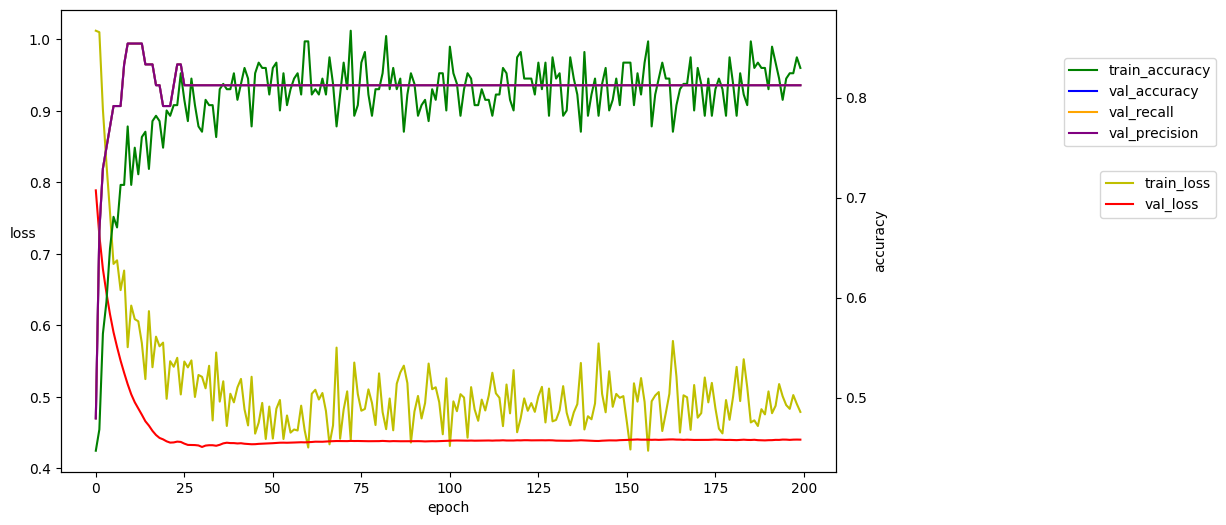

In [44]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'orange', label='val_recall')
acc_ax.plot(hist.history['val_precision'], 'purple', label='val_precision')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

In [45]:
loss, accuracy, recall, precision = model.evaluate(X_test, Y_test)
print(f'정확도 : {accuracy*100:.2f}%')

2/2 [==============================] - 0s 15ms/step - loss: 0.4886 - accuracy: 0.8333 - recall: 0.8333 - precision: 0.8333
정확도 : 83.33%


In [46]:
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1_score:.4f} ({f1_score*100:.2f}%)")

Accuracy : 0.8333 (83.33%)
Precision: 0.8333 (83.33%)
Recall   : 0.8333 (83.33%)
F1-Score : 0.8333 (83.33%)


In [50]:
# 실제값
Y_test.argmax(axis=1)

array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [51]:
# 예측값
model2.predict(X_test).argmax(axis=1)

2/2 [==============================] - 0s 1ms/step


array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0], dtype=int64)

In [55]:
y_hat = model.predict(X_test).argmax(axis=1)
pd.crosstab(y_test.reshape(-1), y_hat, rownames=['실제값'], colnames=['예측값'])

2/2 [==============================] - 0s 5ms/step


예측값,0,1
실제값,,
0,24,8
1,2,26


## 2.4 모델 사용

In [47]:
save_model(model, 'model/05_heart_1.h5')

In [48]:
model2 = load_model('model/05_heart_1.h5')

In [49]:
model2.predict(X_test).argmax(axis=1)

2/2 [==============================] - 0s 0s/step


array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0], dtype=int64)

In [61]:
data = [[ 63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6]]
input_data = scaler.transform(data)
model2.predict(input_data).argmax(axis=1)

1/1 [==============================] - 0s 23ms/step


array([1], dtype=int64)

In [62]:
data = [[ 63,   1,   1, 145, 233,   1,   2, 150,   0,   2,   3,   0,   6],
        [ 67,   1,   4, 160, 286,   0,   0, 108,   1,   1,   2,   3,   3]]
input_data = scaler.transform(data)
model2.predict(input_data).argmax(axis=1)

1/1 [==============================] - 0s 26ms/step


array([1, 1], dtype=int64)